In [1]:
import os
import sys
import pandas as pd
from pathlib import Path
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# Change root directory to the repo root (Jupyter: __file__ is not defined)
def find_repo_root(start=Path.cwd()):
	for p in [start] + list(start.parents):
		if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
			return p
	return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'
geospatial_root = repo_root.parent.parent / 'Data' / 'Geospatial'
geometry_root = repo_root.parent.parent / 'Data' / 'Geospatial' / 'geometry'
gus_root = Path(os.getcwd()).parent.parent.parent.parent / "Data" / "GUS"

os.chdir(repo_root)
sys.path.append(str(repo_root / 'Code' / 'tools'))

# import local toolkit (try normal import first, fall back to loading from file)
try:
	import inequality_analyzers as inqA
	import local_utility_functions as luf
except Exception:
	import importlib.util
	toolkit_path = repo_root / 'Code' / 'tools' / 'inequality_analyzers.py'
	if toolkit_path.exists():
		spec = importlib.util.spec_from_file_location("inequality_analyzers", str(toolkit_path))
		stk = importlib.util.module_from_spec(spec)
		spec.loader.exec_module(stk)
	else:
		raise


In [2]:
v_NCtT = np.vectorize(luf.nuts_code_to_teryt)
v_tostring = np.vectorize(lambda x: str(x))
v_zero_pad = np.vectorize(lambda x, n: str(x).zfill(n))

In [3]:
mega_df = pd.read_csv(geospatial_root / "teryt_df.csv", encoding="utf-8")
mega_df['teryt'] = v_zero_pad(v_tostring(mega_df['id']),7)

In [4]:
mega_df[mega_df['NAZWA'] == "Tyszowce"]

,year,WOJ,POW,GMI,RODZ,id,NAZWA,NAZWA_DOD,level,kind,STAN_NA,if_changed,when_changed,notes,historical_codes,code_by_year,teryt
786,1999,6,18,12,2,618122,Tyszowce,gmina wiejska,6,rural,1999-01-01,False,NaN,"{'number_of_changes': 1, 'changes': ['TYPE_CHA...","['0618122', '0618123']","{1999: '0618122', 2000: '0618123', 2001: '0618...",0618122
4824,2000,6,18,12,3,618123,Tyszowce,gmina miejsko-wiejska,6,urban-rural,2000-01-01,True,2000.0,"{'number_of_changes': 1, 'changes': ['TYPE_CHA...","['0618122', '0618123']","{1999: '0618122', 2000: '0618123', 2001: '0618...",0618123
8078,2000,6,18,12,4,618124,Tyszowce,miasto,6,town,2000-01-01,True,2000.0,"{'number_of_changes': 1, 'changes': ['NEW: gmi...",['0618124'],"{2000: '0618124', 2001: '0618124', 2002: '0618...",0618124
8079,2000,6,18,12,5,618125,Tyszowce,obszar wiejski,6,village,2000-01-01,True,2000.0,"{'number_of_changes': 1, 'changes': ['NEW: gmi...",['0618125'],"{2000: '0618125', 2001: '0618125', 2002: '0618...",0618125
8872,2001,6,18,12,3,618123,Tyszowce,gmina miejsko-wiejska,6,urban-rural,2001-01-01,True,2000.0,"{'number_of_changes': 1, 'changes': ['TYPE_CHA...","['0618122', '0618123']","{1999: '0618122', 2000: '0618123', 2001: '0618...",0618123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102781,2023,6,18,12,4,618124,Tyszowce,miasto,6,town,2023-01-01,True,2000.0,"{'number_of_changes': 1, 'changes': ['NEW: gmi...",['0618124'],"{2000: '0618124', 2001: '0618124', 2002: '0618...",0618124
102782,2023,6,18,12,5,618125,Tyszowce,obszar wiejski,6,village,2023-01-01,True,2000.0,"{'number_of_changes': 1, 'changes': ['NEW: gmi...",['0618125'],"{2000: '0618125', 2001: '0618125', 2002: '0618...",0618125
103797,2024,6,18,12,3,618123,Tyszowce,gmina miejsko-wiejska,6,urban-rural,2024-01-01,True,2000.0,"{'number_of_changes': 1, 'changes': ['TYPE_CHA...","['0618122', '0618123']","{1999: '0618122', 2000: '0618123', 2001: '0618...",0618123
107047,2024,6,18,12,4,618124,Tyszowce,miasto,6,town,2024-01-01,True,2000.0,"{'number_of_changes': 1, 'changes': ['NEW: gmi...",['0618124'],"{2000: '0618124', 2001: '0618124', 2002: '0618...",0618124


In [5]:
geometry_files = [f for f in os.listdir(geometry_root)]
geometry_paths = [geometry_root / f for f in geometry_files]

shape_files = []
for i in range(len(geometry_paths)):
    if geometry_paths[i] != geometry_root / '.DS_Store':
        dir = os.listdir(geometry_paths[i])
        for file in dir:
            if file.endswith('.shp'):
                shape_files.append(geometry_paths[i] / file)

shape_files.sort()
# Now we take only files that contain 'obszary' or 'gmin...' in their names
shape_files = [f for f in shape_files if 'Obszary' in f.name or 'gmin' in f.name]

In [6]:
gdf_list = {}
for file in shape_files:
    key = str(file.parent)[-4:] + "_" + str(file.stem)
    gdf = gpd.read_file(file)
    gdf_list[key] = gdf

In [7]:
# After 2012: column with code is "jpt_kod_je"
# Before and including 2012: column with code is "Obszar" and has to be transformed to teryt
for key in gdf_list:
    print(f"Processing {key}...")
    # find year in the key
    import re
    match = re.search(r'\d{4}', key)
    if match:
        year = match.group(0)
    else:
        continue
    if int(year) > 2012:
        # Change the current column names to lowercase to avoid issues
        gdf_list[key].columns = [col.lower() for col in gdf_list[key].columns]
        gdf_list[key]['teryt'] = gdf_list[key]['jpt_kod_je']
        # Sort by teryt
        gdf_list[key] = gdf_list[key].sort_values(by='teryt').reset_index(drop=True)
    else:
        gdf_list[key].columns = [col.lower() for col in gdf_list[key].columns]
        gdf_list[key]['teryt'] = v_NCtT(v_tostring(gdf_list[key]['obszar'].values))
        # Sort by teryt
        gdf_list[key] = gdf_list[key].sort_values(by='teryt').reset_index(drop=True)

Processing 2005_Obszary...
Processing 2006_Obszary...
Processing 2007_Obszary...
Processing 2008_Obszary...
Processing 2009_Obszary...
Processing 2010_Obszary...
Processing 2011_Obszary...
Processing 2012_Obszary_1992_region...
Processing 2015_gminy...
Processing 2016_gminy...
Processing 2017_gminy...
Processing 2018_gminy...
Processing 2021_A03_Granice_gmin...
Processing 2022_A03_Granice_gmin...
Processing 2023_A03_Granice_gmin...


In [8]:
# For geometries before 2012, we need to combine together all geometries that share all the same first digits in teryt but differ in the last digits
# By combining we mean merging geometries using dissolve function. 
# First we create a new column 'teryt_short' that contains orignal teryt code with last one digit replaced by '0'
# IMPORTANT: Fix invalid geometries before dissolving to avoid TopologyException
for key in gdf_list:
    print(f"Combining geometries for {key}...")
    import re
    match = re.search(r'\d{4}', key)
    if match:
        year = match.group(0)
    else:
        continue
    if int(year) <= 2012:
        # Fix invalid geometries by buffering with 0 distance
        invalid_mask = ~gdf_list[key].is_valid
        if invalid_mask.any():
            print(f"  Fixing {invalid_mask.sum()} invalid geometries...")
            gdf_list[key].loc[invalid_mask, 'geometry'] = gdf_list[key].loc[invalid_mask, 'geometry'].buffer(0)
        
        gdf_list[key]['teryt_short'] = gdf_list[key]['teryt'].str[:-1] + '0'
        gdf_list[key] = gdf_list[key].dissolve(by='teryt_short', as_index=False)
        gdf_list[key]['teryt'] = gdf_list[key]['teryt_short']
        gdf_list[key] = gdf_list[key].drop(columns=['teryt_short'])
        # Sort by teryt
        gdf_list[key] = gdf_list[key].sort_values(by='teryt').reset_index(drop=True)

Combining geometries for 2005_Obszary...
  Fixing 7 invalid geometries...
Combining geometries for 2006_Obszary...
  Fixing 8 invalid geometries...
Combining geometries for 2007_Obszary...
  Fixing 7 invalid geometries...
Combining geometries for 2008_Obszary...
  Fixing 9 invalid geometries...
Combining geometries for 2009_Obszary...
  Fixing 7 invalid geometries...
Combining geometries for 2010_Obszary...
  Fixing 6 invalid geometries...
Combining geometries for 2011_Obszary...
  Fixing 6 invalid geometries...
Combining geometries for 2012_Obszary_1992_region...
  Fixing 9 invalid geometries...
Combining geometries for 2015_gminy...
Combining geometries for 2016_gminy...
Combining geometries for 2017_gminy...
Combining geometries for 2018_gminy...
Combining geometries for 2021_A03_Granice_gmin...
Combining geometries for 2022_A03_Granice_gmin...
Combining geometries for 2023_A03_Granice_gmin...


In [9]:
teryt_df = mega_df.copy()
teryt_df['geometry_available'] = False
teryt_df['geometry_years'] = ""
for id,row in teryt_df.iterrows():
    teryt = row['teryt']
    teryt_old = teryt[:-1] +'0'
    for key in gdf_list:
        import re
        match = re.search(r'\d{4}', key)
        if match:
            year = match.group(0)
        else:
            continue
        if int(year) > 2012:
            if teryt in gdf_list[key]['teryt'].values:
                teryt_df.at[id, 'geometry_available'] = True
                teryt_df.at[id, 'geometry_years'] += key[:4] + " "
        else:
            if teryt_old in gdf_list[key]['teryt'].values:
                teryt_df.at[id, 'geometry_available'] = True
                teryt_df.at[id, 'geometry_years'] += key[:4] + " "

teryt_df.to_csv(geospatial_root / "teryt_df.csv", encoding="utf-8", index=False)

In [10]:
# Gminas for which we DO NOT have geometries
missing_geometries = teryt_df.loc[(teryt_df['geometry_available'] == False) & (teryt_df['level'] == 6) & (teryt_df['RODZ'] < 4)]
missing_geometries

,year,WOJ,POW,GMI,RODZ,id,NAZWA,NAZWA_DOD,level,kind,STAN_NA,if_changed,when_changed,notes,historical_codes,code_by_year,teryt,geometry_available,geometry_years
107,1999,2,10,5,2,210052,Olszyna,gmina wiejska,6,rural,1999-01-01,False,NaN,"{'number_of_changes': 1, 'changes': ['TYPE_CHA...","['0210052', '0210053']","{1999: '0210052', 2000: '0210052', 2001: '0210...",0210052,False,
213,1999,2,20,2,2,220022,Prusice,gmina wiejska,6,rural,1999-01-01,False,NaN,"{'number_of_changes': 1, 'changes': ['TYPE_CHA...","['0220022', '0220023']","{1999: '0220022', 2000: '0220023', 2001: '0220...",0220022,False,
303,1999,2,63,1,1,263011,Wałbrzych,gmina miejska,6,urban,1999-01-01,False,NaN,"{'number_of_changes': 2, 'changes': ['POWIAT_C...","['0263011', '0221091', '0265011']","{1999: '0263011', 2000: '0263011', 2001: '0263...",0263011,False,
623,1999,6,5,6,2,605062,Modliborzyce,gmina wiejska,6,rural,1999-01-01,False,NaN,"{'number_of_changes': 1, 'changes': ['TYPE_CHA...","['0605062', '0605063']","{1999: '0605062', 2000: '0605062', 2001: '0605...",0605062,False,
633,1999,6,6,8,2,606082,Rejowiec,gmina wiejska,6,rural,1999-01-01,False,NaN,"{'number_of_changes': 2, 'changes': ['POWIAT_C...","['0606082', '0603152', '0603153']","{1999: '0606082', 2000: '0606082', 2001: '0606...",0606082,False,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105815,2024,24,4,14,3,2404143,Przyrów,gmina miejsko-wiejska,6,urban-rural,2024-01-01,True,2024.0,"{'number_of_changes': 1, 'changes': ['TYPE_CHA...","['2404142', '2404143']","{1999: '2404142', 2000: '2404142', 2001: '2404...",2404143,False,
106065,2024,26,5,2,3,2605023,Gowarczów,gmina miejsko-wiejska,6,urban-rural,2024-01-01,True,2024.0,"{'number_of_changes': 1, 'changes': ['TYPE_CHA...","['2605022', '2605023']","{1999: '2605022', 2000: '2605022', 2001: '2605...",2605023,False,
106139,2024,26,12,1,3,2612013,Bogoria,gmina miejsko-wiejska,6,urban-rural,2024-01-01,True,2024.0,"{'number_of_changes': 1, 'changes': ['TYPE_CHA...","['2612012', '2612013']","{1999: '2612012', 2000: '2612012', 2001: '2612...",2612013,False,
106472,2024,30,8,6,3,3008063,Rychtal,gmina miejsko-wiejska,6,urban-rural,2024-01-01,True,2024.0,"{'number_of_changes': 1, 'changes': ['TYPE_CHA...","['3008062', '3008063']","{1999: '3008062', 2000: '3008062', 2001: '3008...",3008063,False,


Total number of geometry gminas in 2017: 2478
Number of geometry gminas with geometries in 2017: 2478
Total number of teryt gminas in 2017: 2478
Total number of teryt gminas with geometries in 2017: 2478
Number of teryt gminas without geometries in 2017: 569


<Axes: >

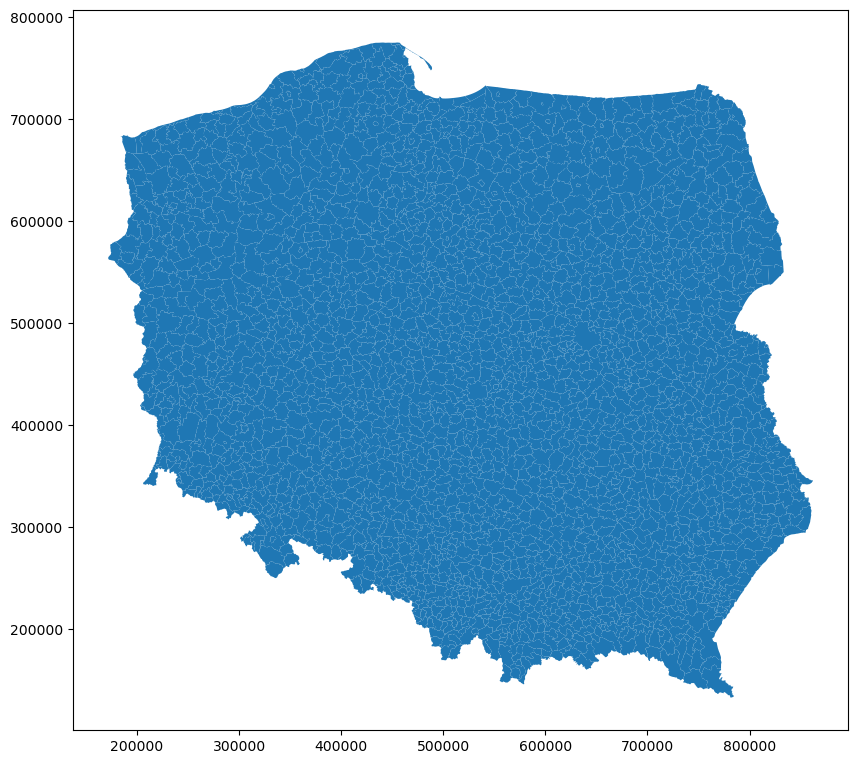

In [11]:
# Replace last with zero function 
v_replace_last = np.vectorize(lambda x,y: str(x)[:-1] + y)

# Choose year 
year = 2017
specific_closest_year = None

# Take the geodataframe for that year and plot only that gminas which have geometries in teryt_df for that year
year_key = None
for key in list(gdf_list.keys()):
    if str(year) in str(key):
        year_key = key
        break
if year_key is None and specific_closest_year is None:
    # We find the closest year available
    available_years = [int(key[:4]) for key in list(gdf_list.keys())]
    closest_year = min(available_years, key=lambda x: abs(x - year))
    year_key = [key for key in list(gdf_list.keys()) if str(closest_year) in str(key)][0]
elif specific_closest_year is not None:
    closest_year = specific_closest_year
    year_key = [key for key in list(gdf_list.keys()) if str(closest_year) in str(key)][0]
else:
    closest_year = year

if int(closest_year) <= 2012:
    selected_teryts = v_replace_last(teryt_df.loc[(teryt_df['level'] == 6) & (teryt_df['RODZ'] < 4) & (teryt_df['year'] == int(year))]['teryt'].values, '0')
else:
    selected_teryts = teryt_df.loc[(teryt_df['geometry_available'] == True) & (teryt_df['level'] == 6) & (teryt_df['RODZ'] < 4) & (teryt_df['year'] == int(year))]['teryt'].values
gdf_year = gdf_list[year_key]
gdf_year_selected = gdf_year[gdf_year['teryt'].isin(selected_teryts)]

print(f"Total number of geometry gminas in {year}: {len(gdf_year)}")
print(f"Number of geometry gminas with geometries in {year}: {len(gdf_year_selected)}")
print(f"Total number of teryt gminas in {year}: {len(teryt_df.loc[(teryt_df['level'] == 6) & (teryt_df['RODZ'] < 4) & (teryt_df['year'] == int(year))])}")
print(f"Total number of teryt gminas with geometries in {year}: {len(selected_teryts)}")
print(f"Number of teryt gminas without geometries in {year}: {len(missing_geometries)}")

gdf_year_selected.plot(figsize=(10,10))